In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_datareader as data
import yfinance as yf


In [26]:
start = '2010-01-01'
end = '2019-12-31'

df = yf.download('AAPL', start=start, end=end)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.440331,6.455077,6.391279,6.422877,493729600
2010-01-05,6.451467,6.487880,6.417461,6.458088,601904800
2010-01-06,6.348846,6.477045,6.342225,6.451465,552160000
2010-01-07,6.337111,6.379844,6.291068,6.372321,477131200
2010-01-08,6.379241,6.379843,6.291368,6.328683,447610800


In [27]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-12-23,68.757668,68.818194,67.878827,67.917565,98572000
2019-12-24,68.823013,68.973124,68.496178,68.924700,48478800
2019-12-26,70.188492,70.205441,68.927130,68.956181,93121200
2019-12-27,70.161865,71.171444,69.755132,70.481445,146266000
2019-12-30,70.578278,70.861543,69.053023,70.079543,144114400


In [28]:
df = df.reset_index()
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2010-01-04,6.440331,6.455077,6.391279,6.422877,493729600
1,2010-01-05,6.451467,6.487880,6.417461,6.458088,601904800
2,2010-01-06,6.348846,6.477045,6.342225,6.451465,552160000
3,2010-01-07,6.337111,6.379844,6.291068,6.372321,477131200
4,2010-01-08,6.379241,6.379843,6.291368,6.328683,447610800


In [29]:
df = df.drop(columns=['Date'], axis=1)
df.head()

C:\Users\Rishav\AppData\Local\Temp\ipykernel_14136\4009408605.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(columns=['Date'], axis=1)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
0,6.440331,6.455077,6.391279,6.422877,493729600
1,6.451467,6.487880,6.417461,6.458088,601904800
2,6.348846,6.477045,6.342225,6.451465,552160000
3,6.337111,6.379844,6.291068,6.372321,477131200
4,6.379241,6.379843,6.291368,6.328683,447610800


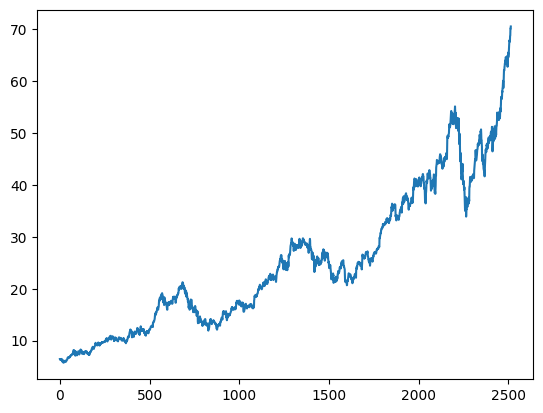

In [30]:
plt.plot(df['Close'])

In [32]:
ma100 = df.Close.rolling(100).mean()
ma100

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2510,57.212838
2511,57.410470
2512,57.647437
2513,57.875338


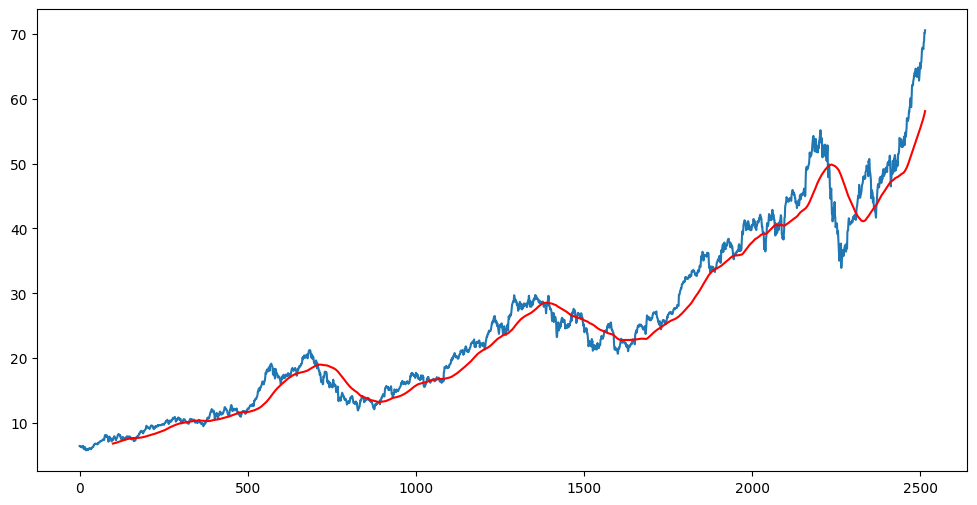

In [33]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='AAPL')
plt.plot(ma100, 'r', label='MA100')

In [34]:
ma200 = df.Close.rolling(200).mean()
ma200

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2510,52.164465
2511,52.291901
2512,52.425206
2513,52.555958


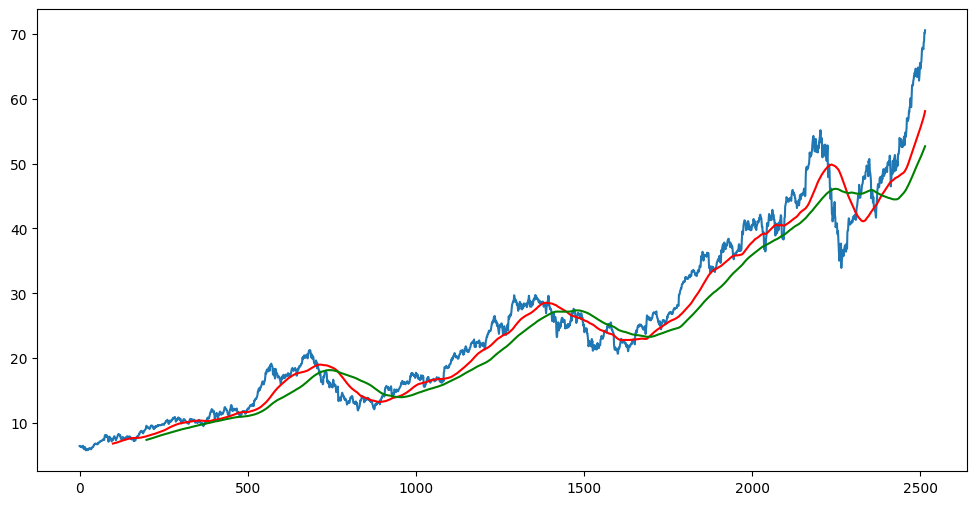

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='AAPL')
plt.plot(ma100, 'r', label='MA100')
plt.plot(ma200, 'g', label='MA200')

In [36]:
df.shape

(2515, 5)

In [38]:
# Splitting the data into training and testing data

data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.7)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.7):int(len(df))])
data_training.shape, data_testing.shape

((1760, 1), (755, 1))

In [39]:
data_training.head()

Ticker,AAPL
0,6.440331
1,6.451467
2,6.348846
3,6.337111
4,6.379241


In [40]:
data_testing.head()

Ticker,AAPL
1760,26.996561
1761,26.786106
1762,26.862429
1763,26.832363
1764,26.968807


In [41]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

In [42]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.02760003],
       [0.0280651 ],
       [0.02377922],
       ...,
       [0.88408415],
       [0.89123193],
       [0.88640262]])

In [43]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i, 0])

In [44]:
x_train

[array([[2.76000304e-02],
        [2.80650979e-02],
        [2.37792203e-02],
        [2.32891201e-02],
        [2.50486217e-02],
        [2.26983313e-02],
        [1.96945208e-02],
        [2.33770434e-02],
        [2.18437327e-02],
        [1.74448194e-02],
        [2.88945243e-02],
        [2.47344477e-02],
        [2.01343763e-02],
        [7.16388704e-03],
        [1.38502201e-02],
        [1.74573657e-02],
        [1.98956391e-02],
        [9.09943438e-03],
        [1.25064175e-05],
        [3.36828890e-03],
        [4.78846430e-03],
        [9.02399758e-03],
        [0.00000000e+00],
        [4.28569835e-03],
        [2.60165348e-03],
        [5.20328704e-03],
        [3.85844886e-03],
        [8.32013322e-03],
        [1.04694447e-02],
        [1.42650429e-02],
        [1.31967598e-02],
        [1.36743536e-02],
        [1.20906389e-02],
        [1.05197094e-02],
        [6.29668249e-03],
        [1.08212972e-02],
        [1.25053620e-02],
        [1.57983934e-02],
        [2.1

In [45]:
y_train

[0.0770438732295354,
 0.08148044518066797,
 0.08644481583105343,
 0.09036631456189106,
 0.08932312400750228,
 0.0803241591724416,
 0.07401477111463647,
 0.07199134030161178,
 0.06428706848378804,
 0.07347432659513578,
 0.07724491189945795,
 0.07821276522865436,
 0.0850120742690019,
 0.09451378513895067,
 0.1003204271618677,
 0.10308534116431559,
 0.0981837017482299,
 0.10280896526920066,
 0.09918919381800614,
 0.09671320195753316,
 0.09382246702228972,
 0.0958334113324871,
 0.08058806847940683,
 0.07475639370680257,
 0.07092311699753576,
 0.06898752982720832,
 0.07111154967656572,
 0.0837300469866902,
 0.08300124944686985,
 0.08492417088227197,
 0.08199573746241604,
 0.07509566015363775,
 0.07626451232340162,
 0.07465578475579229,
 0.07270777082667021,
 0.06727821322326624,
 0.0752088551808631,
 0.07816250058250432,
 0.08416998212856838,
 0.0853262283074396,
 0.08449700104870692,
 0.09052949542978064,
 0.08660835516313906,
 0.08302634194058975,
 0.08194539315755575,
 0.0877269626014304

In [46]:
x_train = np.array(x_train)
y_train = np.array(y_train)
x_train.shape, y_train.shape

((1660, 100, 1), (1660,))

In [47]:
#ML Model

In [48]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

In [51]:
model = Sequential()
model.add(LSTM(units=50, activation = 'relu', return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=60, activation = 'relu', return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(units=80, activation = 'relu', return_sequences=True))
model.add(Dropout(0.4))
model.add(LSTM(units=120, activation = 'relu',))
model.add(Dropout(0.5))

model.add(Dense(units=1))
# model.compile(optimizer='adam', loss='mean_squared_error')

In [52]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 26s 294ms/step - loss: 0.1360
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 284ms/step - loss: 0.0155
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 272ms/step - loss: 0.0118
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 268ms/step - loss: 0.0107
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 272ms/step - loss: 0.0105
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 265ms/step - loss: 0.0082
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 279ms/step - loss: 0.0089
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 277ms/step - loss: 0.0086
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 278ms/step - loss: 0.0083
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 278ms/step - loss: 0.0078
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 279ms/step - loss: 0.0073
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 277ms/step - loss: 0.0067
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 277ms/step - loss: 0.0072
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 279ms/step - loss: 0.0069
Epoch 15/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 16s 

In [54]:
model.save('keras_model.h5')

In [55]:
data_testing.head()

Ticker,AAPL
1760,26.996561
1761,26.786106
1762,26.862429
1763,26.832363
1764,26.968807


In [56]:
data_training.tail(100)

Ticker,AAPL
1660,24.935099
1661,25.036335
1662,24.849962
1663,24.833847
1664,24.891371
...,...
1755,27.072884
1756,26.894812
1757,26.947992
1758,27.119139


In [57]:
past_100_days = data_training.tail(100)

In [59]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)
final_df.head()

Ticker,AAPL
0,24.935099
1,25.036335
2,24.849962
3,24.833847
4,24.891371


In [60]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.02573558],
       [0.0278965 ],
       [0.02391833],
       [0.02357434],
       [0.0248022 ],
       [0.03118723],
       [0.03069591],
       [0.02991019],
       [0.02922259],
       [0.03059763],
       [0.0264231 ],
       [0.02809298],
       [0.02406558],
       [0.02180639],
       [0.01871226],
       [0.01812286],
       [0.01409559],
       [0.01458675],
       [0.01768088],
       [0.02259211],
       [0.02244497],
       [0.0256864 ],
       [0.01173807],
       [0.        ],
       [0.01134515],
       [0.02367275],
       [0.04243406],
       [0.06109734],
       [0.05790489],
       [0.0513237 ],
       [0.0512746 ],
       [0.05117636],
       [0.0564317 ],
       [0.04705085],
       [0.04788571],
       [0.04891717],
       [0.05314104],
       [0.04444796],
       [0.04872073],
       [0.04611759],
       [0.04847535],
       [0.04872073],
       [0.05284628],
       [0.05368118],
       [0.06345469],
       [0.06468267],
       [0.06979042],
       [0.068

In [61]:
input_data.shape

(855, 1)

In [62]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i, 0])

In [63]:
x_test, y_test = np.array(x_test), np.array(y_test)
print(x_test.shape, y_test.shape)

(755, 100, 1) (755,)


In [66]:
# Making predictions
y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step


In [67]:
y_predicted.shape

(755, 1)

In [68]:
y_test

array([0.06973798, 0.06524577, 0.0668749 , 0.06623314, 0.06914557,
       0.07556317, 0.08089476, 0.08148717, 0.08464657, 0.08217823,
       0.0811416 , 0.08588069, 0.08583139, 0.0847946 , 0.08588069,
       0.08627565, 0.08573258, 0.0951615 , 0.09545769, 0.09550707,
       0.09392725, 0.09254509, 0.12907592, 0.12798974, 0.130705  ,
       0.13667826, 0.14279931, 0.14531728, 0.1500273 , 0.14853998,
       0.15434062, 0.16291816, 0.16534769, 0.16455416, 0.16638868,
       0.17124735, 0.17328026, 0.17040475, 0.17104952, 0.17238775,
       0.1726854 , 0.18656749, 0.18245257, 0.18651823, 0.18433676,
       0.18522894, 0.18265076, 0.18106426, 0.18334491, 0.1836426 ,
       0.18260133, 0.18988966, 0.19102994, 0.1875595 , 0.19484742,
       0.18681568, 0.19464907, 0.19217031, 0.19078216, 0.19197204,
       0.20644919, 0.20803584, 0.20709391, 0.20575495, 0.20595355,
       0.21125867, 0.2075398 , 0.20575495, 0.20416845, 0.20332537,
       0.19569042, 0.1965335 , 0.19281463, 0.1966821 , 0.19355

In [69]:
y_predicted

array([[0.15174612],
       [0.15283854],
       [0.15381771],
       [0.15465786],
       [0.15534563],
       [0.15588605],
       [0.15631297],
       [0.1566824 ],
       [0.15704851],
       [0.15745938],
       [0.15794055],
       [0.15849358],
       [0.15911986],
       [0.15981601],
       [0.16056684],
       [0.16135347],
       [0.1621566 ],
       [0.16295475],
       [0.16375516],
       [0.16457398],
       [0.16542004],
       [0.16628832],
       [0.16716024],
       [0.16813132],
       [0.1693142 ],
       [0.17078897],
       [0.17260958],
       [0.17481028],
       [0.1773964 ],
       [0.18035163],
       [0.18361919],
       [0.18705691],
       [0.19060078],
       [0.19417918],
       [0.1977405 ],
       [0.20123075],
       [0.2046059 ],
       [0.20783032],
       [0.21086296],
       [0.2136665 ],
       [0.21621495],
       [0.21849331],
       [0.22053708],
       [0.22238132],
       [0.2240681 ],
       [0.22562595],
       [0.22707406],
       [0.228

In [70]:
scaler.scale_

array([0.02134524])

In [71]:
scale_factor = 1/0.02134524
y_predicted = y_predicted * scale_factor
y_test = y_test * scale_factor

Text(0.5, 1.0, 'AAPL Price Prediction')

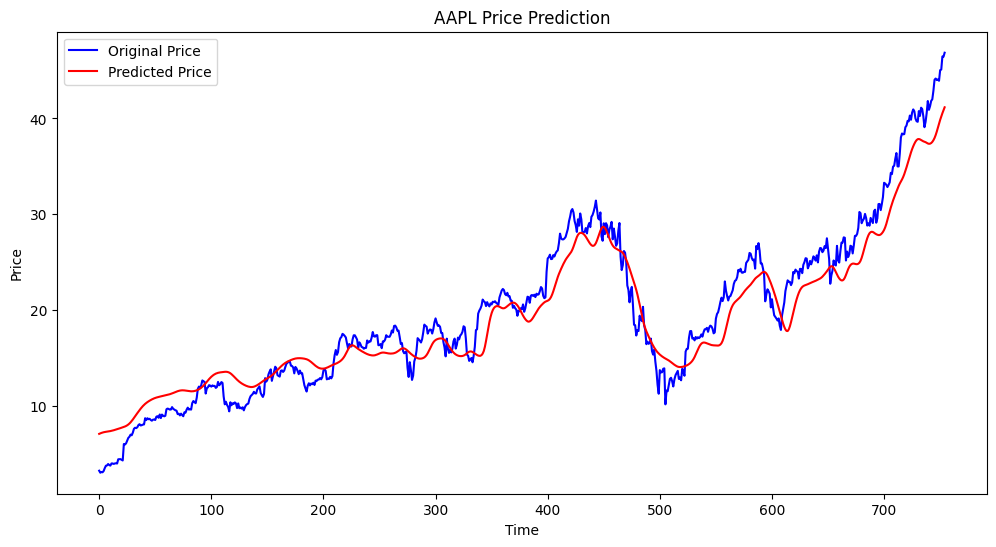

In [72]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.title('AAPL Price Prediction')